## 📦 Step 0: Install Required Libraries

In [ ]:
# Install required libraries
!pip install gradio scikit-learn tensorflow pandas numpy matplotlib seaborn plotly -q

## 📂 Step 1: Upload Dataset

In [1]:
from google.colab import files
print('Please upload your earthquake CSV file')
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f'✅ Uploaded: {CSV_PATH}')

Please upload your earthquake CSV file


Saving Earthquake Time-Series Anomaly Detection. (1) (1).csv to Earthquake Time-Series Anomaly Detection. (1) (1).csv
✅ Uploaded: Earthquake Time-Series Anomaly Detection. (1) (1).csv


## 🔧 Step 2: Import Libraries & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, Dense, LSTM, RepeatVector,
                                      TimeDistributed, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

# Plotting
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print('✅ All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

✅ All libraries imported successfully!
TensorFlow version: 2.19.0


In [3]:
# Load dataset
df = pd.read_csv(CSV_PATH)

print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns: {df.columns.tolist()}')
df.head(10)

📊 Dataset Shape: (17096, 22)
📋 Columns: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2010-12-31T23:18:12.650Z,26.617000,142.937000,10.000,4.10,mb,19.0,114.7,NaN,0.41,...,2014-11-07T01:43:16.958Z,"Bonin Islands, Japan region",earthquake,NaN,NaN,NaN,11.0,reviewed,us,us
1,2010-12-31T23:01:03.440Z,36.678000,140.789000,52.100,4.60,mwr,161.0,109.6,NaN,0.95,...,2014-11-07T01:43:16.945Z,"7 km ESE of Takahagi, Japan",earthquake,NaN,3.60,NaN,NaN,reviewed,us,nied
2,2010-12-31T22:49:31.720Z,27.284000,143.401000,11.900,4.30,mb,24.0,107.5,NaN,0.52,...,2014-11-07T01:43:16.943Z,"Bonin Islands, Japan region",earthquake,NaN,21.80,NaN,12.0,reviewed,us,us
3,2010-12-31T22:32:13.290Z,-24.050000,-176.382000,17.700,4.50,mb,17.0,87.3,NaN,0.73,...,2014-11-07T01:43:16.941Z,south of the Fiji Islands,earthquake,NaN,21.90,NaN,6.0,reviewed,us,us
4,2010-12-31T22:04:44.350Z,11.884000,44.059000,10.000,4.80,mb,48.0,95.0,NaN,0.72,...,2014-11-07T01:43:16.937Z,"84 km E of Obock, Djibouti",earthquake,NaN,NaN,NaN,22.0,reviewed,us,us
5,2010-12-31T21:34:57.000Z,27.345000,143.458000,3.700,4.30,mb,23.0,86.1,NaN,0.72,...,2014-11-07T01:43:16.935Z,"Bonin Islands, Japan region",earthquake,NaN,12.00,NaN,9.0,reviewed,us,us
6,2010-12-31T20:57:36.720Z,40.597000,27.367000,8.600,4.50,ml,33.0,44.7,NaN,NaN,...,2014-11-07T01:43:16.932Z,"15 km W of Marmara, Turkey",earthquake,NaN,NaN,NaN,NaN,reviewed,isk,the
7,2010-12-31T19:32:32.140Z,27.102000,143.415000,10.000,4.60,mb,11.0,139.0,NaN,0.94,...,2014-11-07T01:43:16.930Z,"Bonin Islands, Japan region",earthquake,NaN,NaN,NaN,1.0,reviewed,us,us
8,2010-12-31T19:00:39.145Z,58.188500,-156.055700,146.100,3.70,ml,NaN,NaN,NaN,0.86,...,2018-07-06T22:31:42.644Z,"65 km SSE of King Salmon, Alaska",earthquake,NaN,0.00,NaN,NaN,reviewed,ak,ak
9,2010-12-31T18:34:35.570Z,31.221833,-115.630667,1.375,3.86,ml,5.0,182.0,0.2258,0.27,...,2016-03-14T20:08:47.721Z,"104km ESE of Maneadero, B.C., MX",earthquake,1.37,1.31,0.189,25.0,reviewed,ci,ci


## 📊 Step 3: Exploratory Data Analysis (EDA)

In [4]:
print('='*60)
print('DATASET INFORMATION')
print('='*60)
print(f'Total Records  : {len(df)}')
print(f'Total Features : {df.shape[1]}')
print(f'Date Range     : {df["time"].min()} to {df["time"].max()}')
print()
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print('--- Data Types ---')
print(df.dtypes)

DATASET INFORMATION
Total Records  : 17096
Total Features : 22
Date Range     : 2010-01-01T02:08:21.900Z to 2010-12-31T23:18:12.650Z

--- Missing Values ---
time                   0
latitude               0
longitude              0
depth                  0
mag                    0
magType                0
nst                  516
gap                  521
dmin               15264
rms                 3920
net                    0
id                     0
updated                0
place                  0
type                   0
horizontalError    15244
depthError          9968
magError           15380
magNst              5845
status                 0
locationSource         0
magSource              0
dtype: int64

--- Data Types ---
time                object
latitude           float64
longitude          float64
depth              float64
mag                float64
magType             object
nst                float64
gap                float64
dmin               float64
rms              

In [5]:
# Statistical summary of numeric features
print('--- Statistical Summary ---')
df[['latitude', 'longitude', 'depth', 'mag', 'gap', 'rms']].describe().round(3)

--- Statistical Summary ---


,latitude,longitude,depth,mag,gap,rms
count,17096.000,17096.000,17096.000,17096.000,16575.000,13176.000
mean,9.557,-10.774,44.664,4.258,129.360,0.864
std,32.798,126.149,78.973,0.705,69.599,0.349
min,-80.732,-179.981,-2.600,3.000,9.300,0.010
25%,-18.389,-115.649,10.000,3.800,76.500,0.720
50%,13.857,-70.392,24.700,4.300,116.600,0.910
75%,34.266,128.160,39.800,4.700,172.950,1.090
max,85.398,179.993,643.700,8.800,354.200,4.730


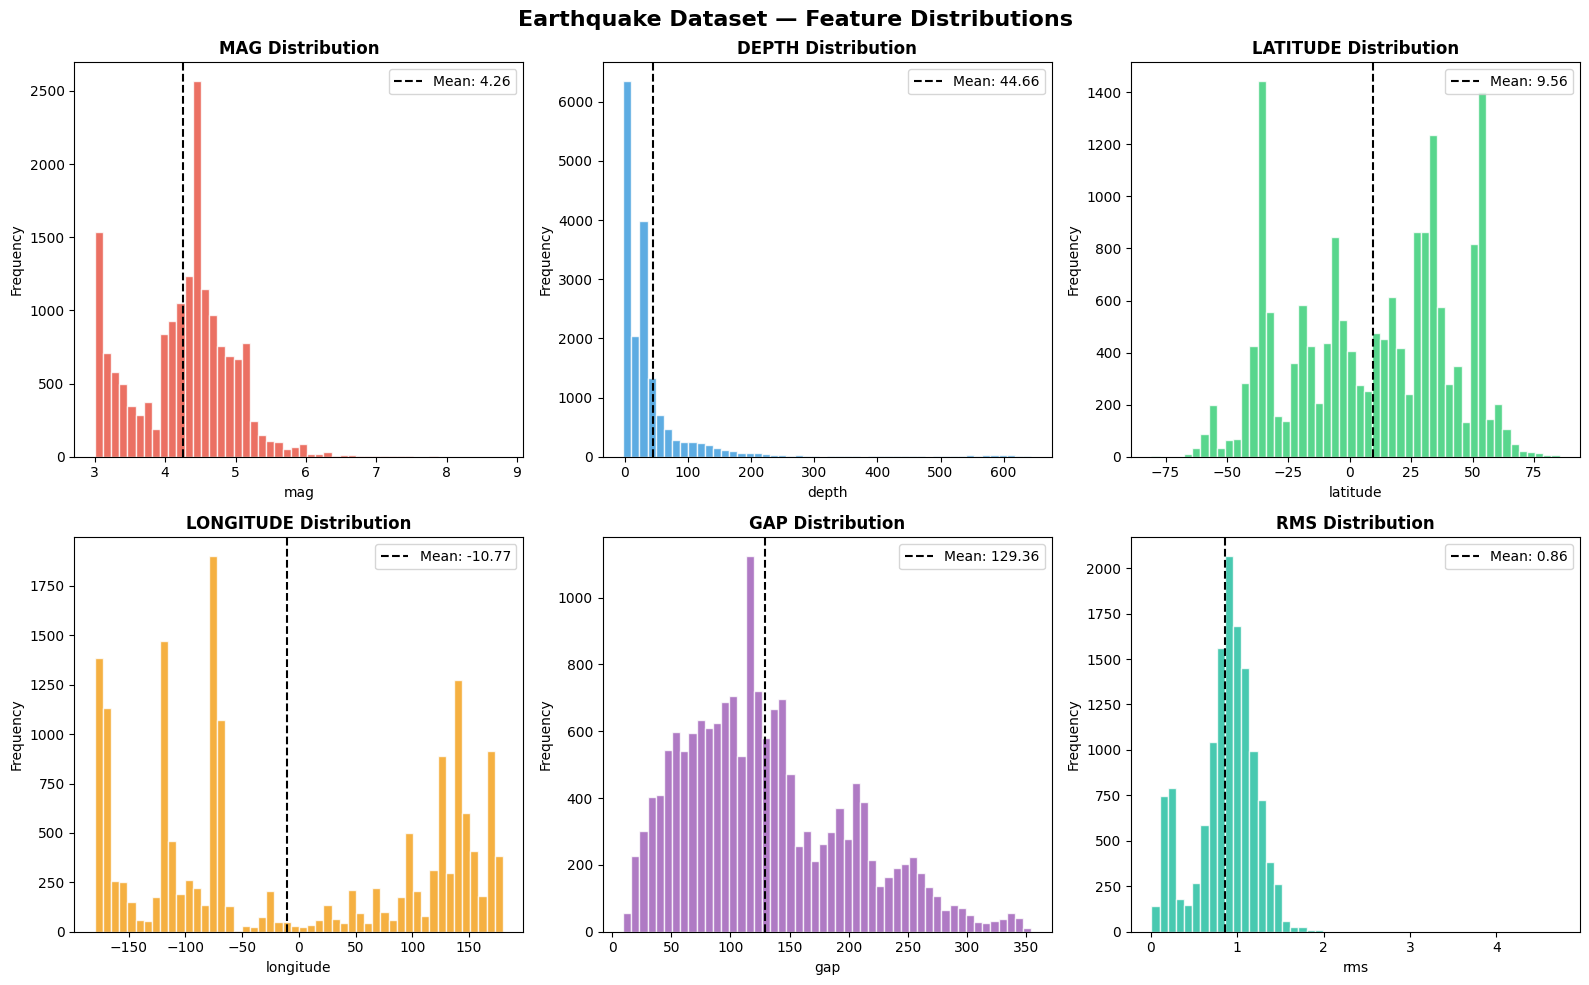

✅ Feature distribution plots saved.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Earthquake Dataset — Feature Distributions', fontsize=16, fontweight='bold')

cols = ['mag', 'depth', 'latitude', 'longitude', 'gap', 'rms']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for ax, col, color in zip(axes.flatten(), cols, colors):
    data = df[col].dropna()
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col.upper()} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='black', linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature distribution plots saved.')

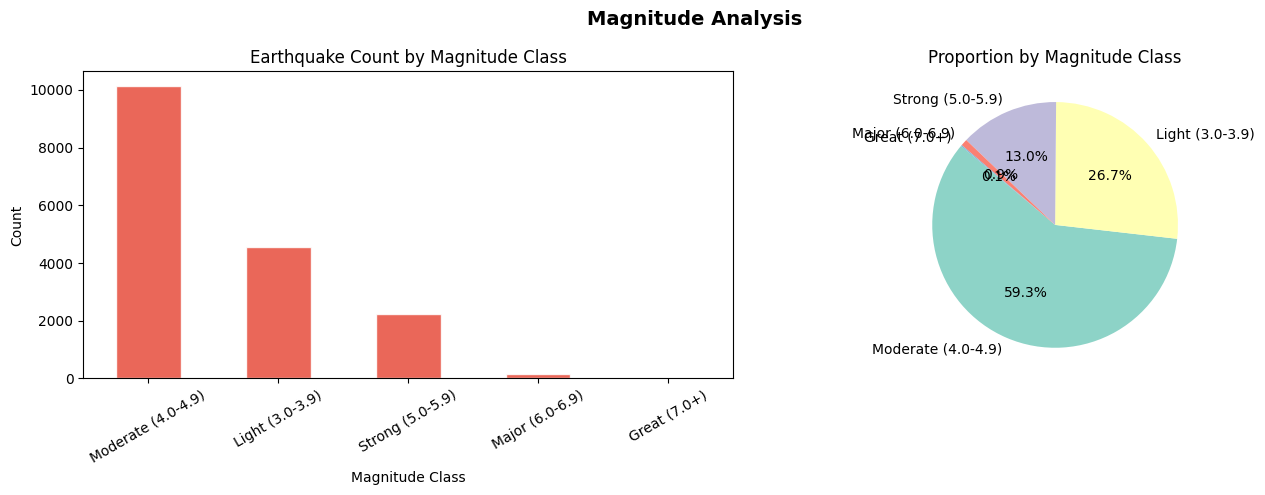

In [7]:
# Magnitude category distribution
def classify_magnitude(mag):
    if mag < 3.0:   return 'Minor (<3.0)'
    elif mag < 4.0: return 'Light (3.0-3.9)'
    elif mag < 5.0: return 'Moderate (4.0-4.9)'
    elif mag < 6.0: return 'Strong (5.0-5.9)'
    elif mag < 7.0: return 'Major (6.0-6.9)'
    else:           return 'Great (7.0+)'

df['mag_category'] = df['mag'].apply(classify_magnitude)
mag_counts = df['mag_category'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Magnitude Analysis', fontsize=14, fontweight='bold')

# Bar plot
mag_counts.plot(kind='bar', ax=ax1, color='#e74c3c', edgecolor='white', alpha=0.85)
ax1.set_title('Earthquake Count by Magnitude Class')
ax1.set_xlabel('Magnitude Class')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=30)

# Pie chart
ax2.pie(mag_counts, labels=mag_counts.index, autopct='%1.1f%%',
        colors=plt.cm.Set3.colors, startangle=140)
ax2.set_title('Proportion by Magnitude Class')

plt.tight_layout()
plt.savefig('magnitude_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Geographic scatter plot
fig = px.scatter_geo(
    df.dropna(subset=['latitude', 'longitude', 'mag']),
    lat='latitude', lon='longitude',
    color='mag',
    size=df['mag'].clip(lower=0.1) ** 2,
    hover_name='place',
    color_continuous_scale='Reds',
    title='🌍 Global Earthquake Distribution by Magnitude',
    projection='natural earth'
)
fig.update_layout(height=500)
fig.show()
print('✅ Geographic distribution map rendered.')

✅ Geographic distribution map rendered.


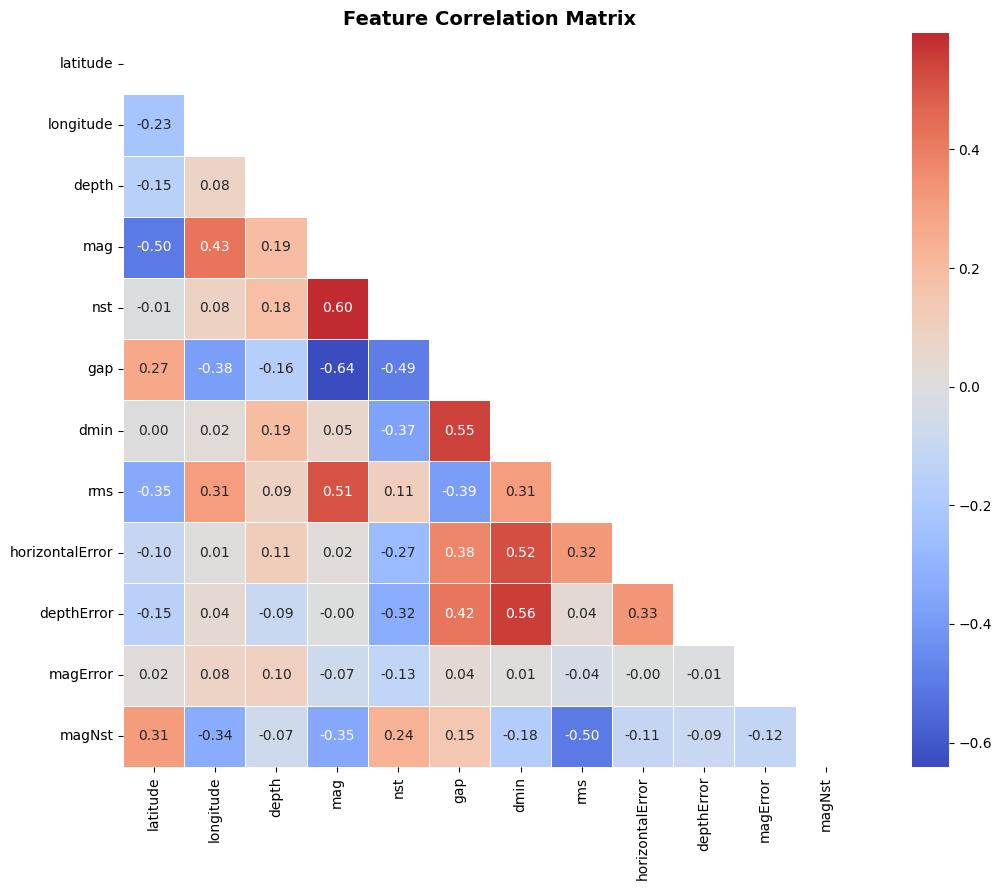

✅ Correlation heatmap saved.


In [9]:
# Correlation heatmap
numeric_cols = ['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'dmin', 'rms',
                'horizontalError', 'depthError', 'magError', 'magNst']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap saved.')

## ⚙️ Step 4: Data Preprocessing & Feature Engineering

In [10]:
# ---- Feature Selection ----
FEATURE_COLS = ['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'rms']

# Parse timestamps
df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')
df['hour']      = df['time'].dt.hour
df['dayofweek'] = df['time'].dt.dayofweek
df['month']     = df['time'].dt.month
df['year']      = df['time'].dt.year

FEATURE_COLS += ['hour', 'dayofweek', 'month']

# Create anomaly label: magnitude >= 5.5 marked as anomaly (1), else normal (0)
ANOMALY_THRESHOLD = 5.5
df['anomaly_label'] = (df['mag'] >= ANOMALY_THRESHOLD).astype(int)

print(f'Anomaly label distribution:')
print(df['anomaly_label'].value_counts())
print(f'\nAnomaly rate: {df["anomaly_label"].mean()*100:.2f}%')

# ---- Handle Missing Values ----
df_clean = df[FEATURE_COLS + ['anomaly_label']].copy()
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

print(f'\n✅ Clean dataset shape: {df_clean.shape}')
print(f'Missing values after imputation: {df_clean.isnull().sum().sum()}')

Anomaly label distribution:
anomaly_label
0    16537
1      559
Name: count, dtype: int64

Anomaly rate: 3.27%

✅ Clean dataset shape: (17096, 11)
Missing values after imputation: 0


In [11]:
# ---- Normalization ----
X = df_clean[FEATURE_COLS].values
y = df_clean['anomaly_label'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape : {X_scaled.shape}')
print(f'Labels shape         : {y.shape}')
print(f'Feature range after scaling: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]')

Feature matrix shape : (17096, 10)
Labels shape         : (17096,)
Feature range after scaling: [0.000, 1.000]


In [12]:
# ---- Train/Test Split (80/20) ----
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set (NEW) : {X_test.shape[0]} samples')
print(f'Train anomaly% : {y_train.mean()*100:.2f}%')
print(f'Test  anomaly% : {y_test.mean()*100:.2f}%')

Training set   : 13676 samples
Test set (NEW) : 3420 samples
Train anomaly% : 3.27%
Test  anomaly% : 3.27%


## 🤖 Step 5: Model 1 — Isolation Forest (Anomaly Detection)

In [13]:
print('Training Isolation Forest...')

# Isolation Forest — unsupervised anomaly detection
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=float(y_train.mean()),  # Expected anomaly proportion
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)

# Predict: Isolation Forest returns -1 for anomaly, 1 for normal
iso_train_pred_raw = iso_forest.predict(X_train)
iso_test_pred_raw  = iso_forest.predict(X_test)

# Convert to binary: -1 -> 1 (anomaly), 1 -> 0 (normal)
iso_train_pred = (iso_train_pred_raw == -1).astype(int)
iso_test_pred  = (iso_test_pred_raw  == -1).astype(int)

# Anomaly scores (lower = more anomalous)
iso_test_scores = -iso_forest.score_samples(X_test)

print('✅ Isolation Forest trained!')
print(f'Predicted anomalies in test set: {iso_test_pred.sum()} / {len(iso_test_pred)}')

Training Isolation Forest...
✅ Isolation Forest trained!
Predicted anomalies in test set: 114 / 3420


## 🧠 Step 6: Model 2 — LSTM Autoencoder (Deep Learning)

In [14]:
# Reshape data for LSTM: (samples, timesteps, features)
TIMESTEPS = 1
X_train_lstm = X_train.reshape((X_train.shape[0], TIMESTEPS, X_train.shape[1]))
X_test_lstm  = X_test.reshape((X_test.shape[0], TIMESTEPS, X_test.shape[1]))

n_features = X_train.shape[1]

# ---- Build LSTM Autoencoder ----
def build_lstm_autoencoder(timesteps, n_features):
    """
    LSTM Autoencoder architecture:
    Encoder: LSTM(64) -> LSTM(32)
    Decoder: RepeatVector -> LSTM(32) -> LSTM(64) -> Dense
    """
    inputs = Input(shape=(timesteps, n_features))

    # Encoder
    x = LSTM(64, activation='relu', return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    encoded = LSTM(32, activation='relu', return_sequences=False)(x)

    # Bottleneck -> Decoder
    x = RepeatVector(timesteps)(encoded)
    x = LSTM(32, activation='relu', return_sequences=True)(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, activation='relu', return_sequences=True)(x)
    outputs = TimeDistributed(Dense(n_features))(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm_autoencoder(TIMESTEPS, n_features)
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 10)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 64)          │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 10)          │           650 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,418 (255.54 KB)

 Trainable params: 65,418 (255.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train only on NORMAL samples (autoencoder learns normal patterns)
X_train_normal = X_train_lstm[y_train == 0]

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print(f'Training on {X_train_normal.shape[0]} normal samples...')

history = lstm_model.fit(
    X_train_normal, X_train_normal,
    epochs=60,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

print('\n✅ LSTM Autoencoder training complete!')

Training on 13229 normal samples...
Epoch 1/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0917 - val_loss: 0.0462
Epoch 2/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0462 - val_loss: 0.0423
Epoch 3/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0429 - val_loss: 0.0389
Epoch 4/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0352 - val_loss: 0.0278
Epoch 5/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0268 - val_loss: 0.0199
Epoch 6/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0217 - val_loss: 0.0145
Epoch 7/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0159 - val_loss: 0.0099
Epoch 8/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0136 - val_loss: 0.0090
Epoch 9/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0127 - val_loss: 0.0087
Epoch 10/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0120 - val_loss: 0.0084
Epoch 11/60
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0116 - val_loss: 0.0084
Epoch 12/60
17

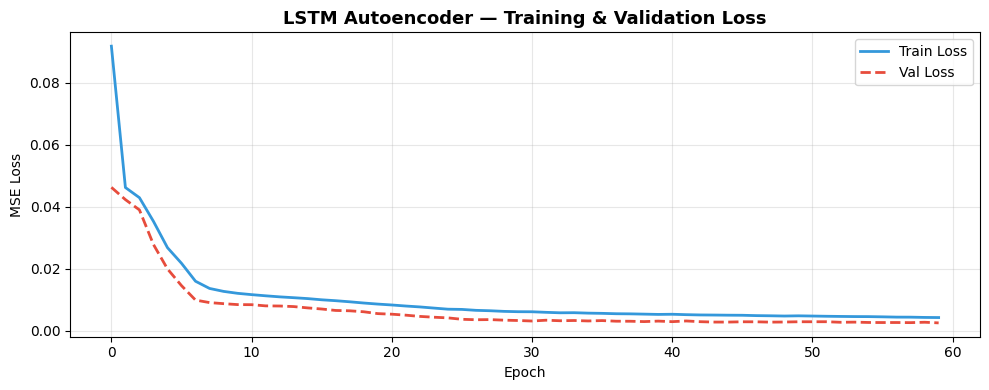

In [16]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss', color='#3498db', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2, linestyle='--')
plt.title('LSTM Autoencoder — Training & Validation Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Compute reconstruction error on test set
X_test_reconstructed = lstm_model.predict(X_test_lstm, verbose=0)
reconstruction_errors = np.mean(np.power(X_test_lstm - X_test_reconstructed, 2), axis=(1, 2))

# Set threshold: mean + 2*std of reconstruction error on normal training data
X_train_normal_reconstructed = lstm_model.predict(X_train_normal, verbose=0)
train_errors = np.mean(np.power(X_train_normal - X_train_normal_reconstructed, 2), axis=(1, 2))
LSTM_THRESHOLD = train_errors.mean() + 2 * train_errors.std()

lstm_test_pred = (reconstruction_errors > LSTM_THRESHOLD).astype(int)

print(f'LSTM Anomaly Threshold (MSE): {LSTM_THRESHOLD:.6f}')
print(f'Predicted anomalies          : {lstm_test_pred.sum()} / {len(lstm_test_pred)}')

LSTM Anomaly Threshold (MSE): 0.006244
Predicted anomalies          : 221 / 3420


## 📈 Step 7: Testing on New Data — Evaluation & Analysis

  MODEL: Isolation Forest
  Accuracy  : 96.32%
  Precision : 43.86%
  Recall    : 44.64%
  F1-Score  : 44.25%
  ROC-AUC   : 0.9585

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      3308
     Anomaly       0.44      0.45      0.44       112

    accuracy                           0.96      3420
   macro avg       0.71      0.71      0.71      3420
weighted avg       0.96      0.96      0.96      3420



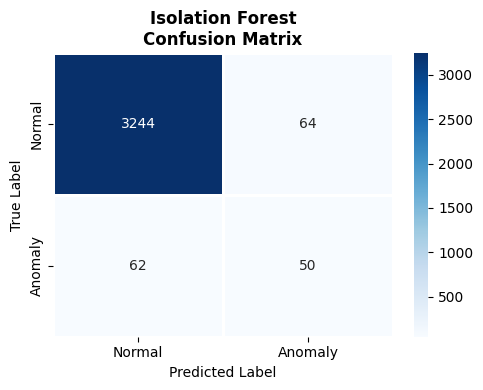

In [18]:
def evaluate_model(name, y_true, y_pred, scores=None):
    """
    Comprehensive model evaluation function.
    Prints all key metrics and plots confusion matrix.
    """
    print('='*55)
    print(f'  MODEL: {name}')
    print('='*55)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec*100:.2f}%')
    print(f'  Recall    : {rec*100:.2f}%')
    print(f'  F1-Score  : {f1*100:.2f}%')

    if scores is not None:
        try:
            auc = roc_auc_score(y_true, scores)
            print(f'  ROC-AUC   : {auc:.4f}')
        except:
            pass

    print()
    print('  Classification Report:')
    print(classification_report(y_true, y_pred,
          target_names=['Normal', 'Anomaly'], zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'],
                linewidths=1)
    plt.title(f'{name}\nConfusion Matrix', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_confusion_matrix.png', dpi=150)
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


# Evaluate Isolation Forest
iso_metrics = evaluate_model('Isolation Forest', y_test, iso_test_pred, iso_test_scores)

  MODEL: LSTM Autoencoder
  Accuracy  : 94.59%
  Precision : 33.48%
  Recall    : 66.07%
  F1-Score  : 44.44%
  ROC-AUC   : 0.9283

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97      3308
     Anomaly       0.33      0.66      0.44       112

    accuracy                           0.95      3420
   macro avg       0.66      0.81      0.71      3420
weighted avg       0.97      0.95      0.95      3420



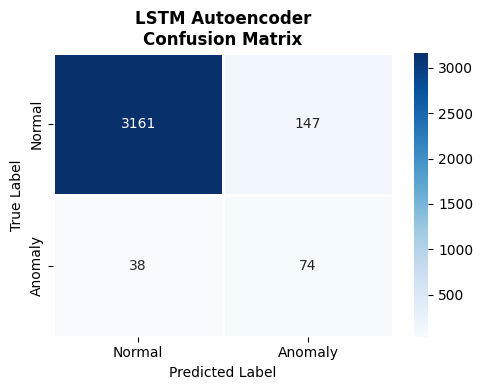

In [19]:
# Evaluate LSTM Autoencoder
lstm_metrics = evaluate_model('LSTM Autoencoder', y_test, lstm_test_pred, reconstruction_errors)

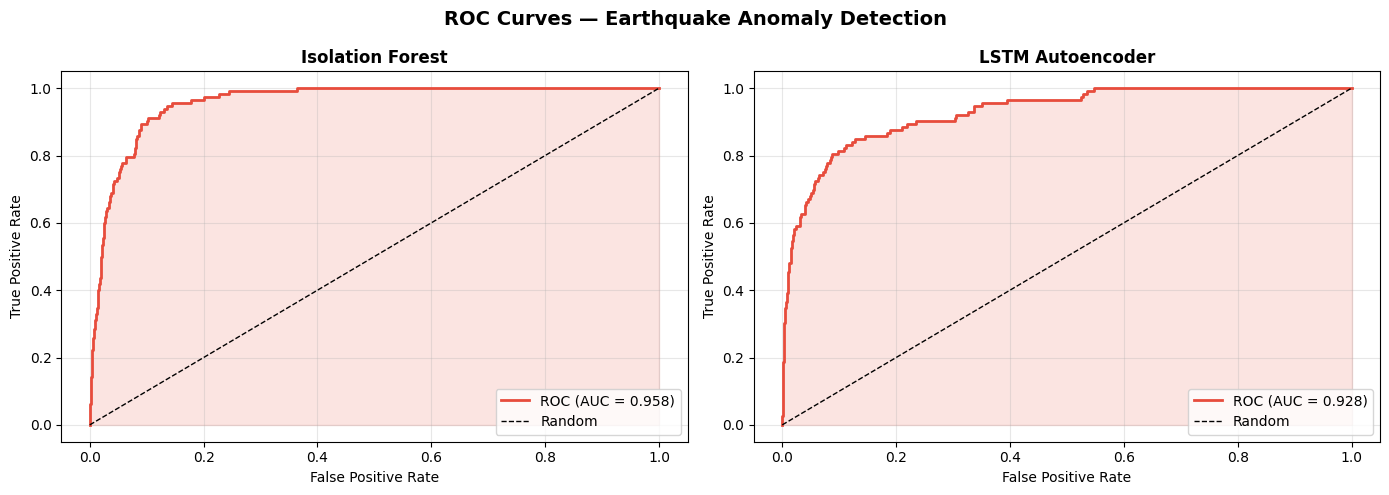

In [20]:
# ROC Curves — Both Models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROC Curves — Earthquake Anomaly Detection', fontsize=14, fontweight='bold')

for ax, name, scores in zip(axes,
    ['Isolation Forest', 'LSTM Autoencoder'],
    [iso_test_scores, reconstruction_errors]):
    try:
        fpr, tpr, _ = roc_curve(y_test, scores)
        auc = roc_auc_score(y_test, scores)
        ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {auc:.3f})')
        ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
        ax.fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
        ax.set_title(name, fontweight='bold')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3)
    except Exception as e:
        ax.set_title(f'{name}\n(ROC not available)')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

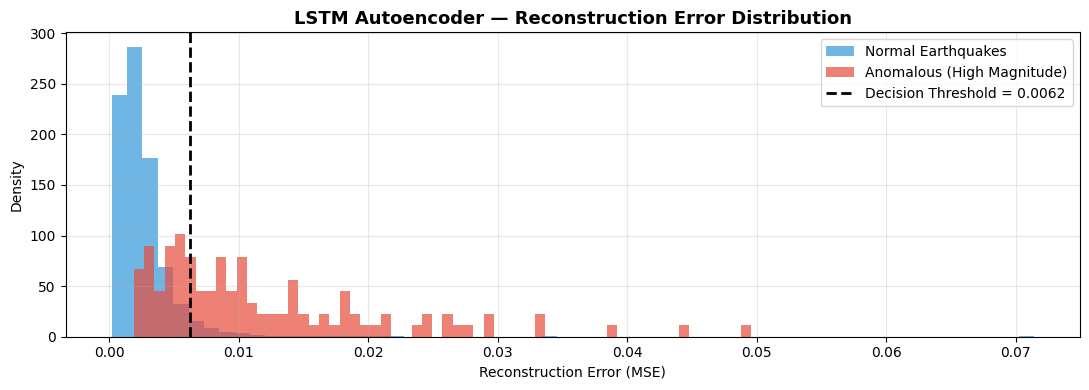

In [21]:
# Reconstruction Error Distribution — LSTM
plt.figure(figsize=(11, 4))

plt.hist(reconstruction_errors[y_test == 0], bins=60,
         color='#3498db', alpha=0.7, label='Normal Earthquakes', density=True)
plt.hist(reconstruction_errors[y_test == 1], bins=60,
         color='#e74c3c', alpha=0.7, label='Anomalous (High Magnitude)', density=True)
plt.axvline(LSTM_THRESHOLD, color='black', linestyle='--', lw=2,
            label=f'Decision Threshold = {LSTM_THRESHOLD:.4f}')

plt.title('LSTM Autoencoder — Reconstruction Error Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reconstruction_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

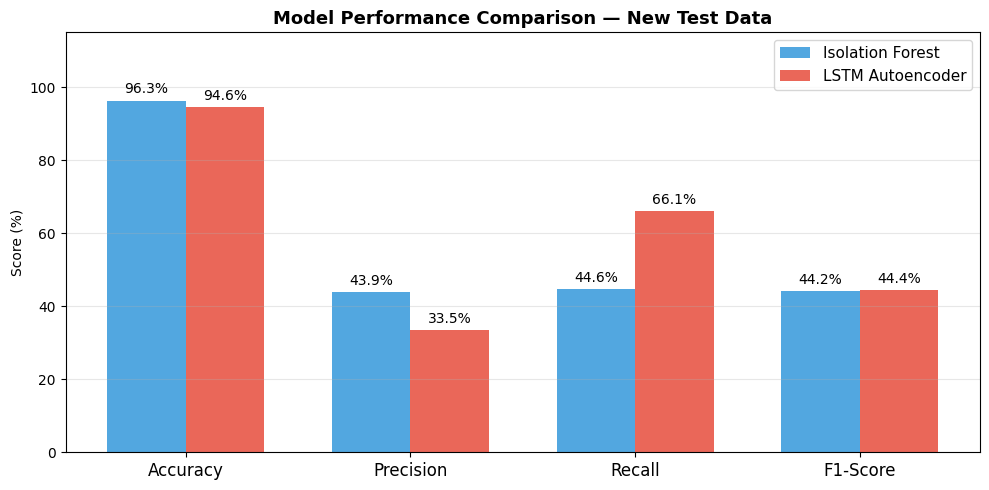

In [22]:
# Side-by-side model comparison
metrics = ['accuracy', 'precision', 'recall', 'f1']
labels  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

iso_vals  = [iso_metrics[m]*100  for m in metrics]
lstm_vals = [lstm_metrics[m]*100 for m in metrics]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, iso_vals,  width, label='Isolation Forest',  color='#3498db', alpha=0.85)
b2 = ax.bar(x + width/2, lstm_vals, width, label='LSTM Autoencoder', color='#e74c3c', alpha=0.85)

ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=10)
ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=10)

ax.set_title('Model Performance Comparison — New Test Data', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Annotate test samples with predictions
test_indices = df_clean.iloc[len(X_train):].index[:len(y_test)]

results_df = df.loc[test_indices[:len(y_test)]].copy() if len(test_indices) == len(y_test) else df.iloc[-len(y_test):].copy()
results_df['true_label']       = y_test
results_df['iso_pred']         = iso_test_pred
results_df['lstm_pred']        = lstm_test_pred
results_df['iso_anomaly_score'] = iso_test_scores
results_df['lstm_recon_error']  = reconstruction_errors

# Top 10 most anomalous by LSTM reconstruction error
print('Top 10 Most Anomalous Earthquakes (LSTM Score):')
top10 = results_df.nlargest(10, 'lstm_recon_error')[['time','place','mag','depth','true_label','lstm_recon_error']]
print(top10.to_string(index=False))

Top 10 Most Anomalous Earthquakes (LSTM Score):
                            time                            place  mag  depth  true_label  lstm_recon_error
2010-01-09 09:44:46.040000+00:00    South Sandwich Islands region  4.6   10.0           0          0.071388
2010-03-12 12:46:51.900000+00:00    34 km W of San Antonio, Chile  4.2    5.7           1          0.049551
2010-02-06 07:05:46.040000+00:00     198 km SSE of Akutan, Alaska  3.0   10.0           1          0.044636
2010-03-12 03:10:46.850000+00:00    56 km NW of Santa Cruz, Chile  4.8   19.4           1          0.038437
2010-01-19 18:49:13.730000+00:00         17 km W of K?zer?n, Iran  4.4   10.0           0          0.034375
2010-02-28 04:12:51.630000+00:00 59 km NNW of Constitución, Chile  4.6   36.2           1          0.033590
2010-03-09 06:34:30.390000+00:00       17 km WNW of Yumbel, Chile  4.5   35.0           1          0.032920
2010-02-27 11:38:51.710000+00:00          55 km NW of Tomé, Chile  4.1   35.0           

## 🌐 Step 9: Deployment — Gradio Web Interface

In [24]:
import gradio as gr

def predict_earthquake(latitude, longitude, depth, magnitude,
                       nst, gap, rms, hour, dayofweek, month):
    """
    Predict whether an earthquake event is anomalous.

    Parameters:
    -----------
    latitude, longitude : Geographic coordinates
    depth               : Earthquake depth in km
    magnitude           : Richter scale magnitude
    nst                 : Number of seismic stations
    gap                 : Azimuthal gap in degrees
    rms                 : Root mean square residual
    hour, dayofweek, month : Time features

    Returns:
    --------
    str : Prediction result with anomaly scores
    """
    try:
        # Build feature vector
        features = np.array([[latitude, longitude, depth, magnitude,
                               nst, gap, rms, hour, dayofweek, month]])

        # Scale
        features_scaled = scaler.transform(features)

        # --- Isolation Forest Prediction ---
        iso_raw   = iso_forest.predict(features_scaled)
        iso_pred  = 1 if iso_raw[0] == -1 else 0
        iso_score = float(-iso_forest.score_samples(features_scaled)[0])

        # --- LSTM Autoencoder Prediction ---
        features_lstm = features_scaled.reshape((1, 1, features_scaled.shape[1]))
        reconstructed = lstm_model.predict(features_lstm, verbose=0)
        recon_error   = float(np.mean(np.power(features_lstm - reconstructed, 2)))
        lstm_pred     = 1 if recon_error > LSTM_THRESHOLD else 0

        # Magnitude classification
        mag_class = classify_magnitude(magnitude)

        # Ensemble decision
        ensemble_pred = 1 if (iso_pred + lstm_pred) >= 1 else 0
        label = '🚨 ANOMALY DETECTED (High-Risk Event)' if ensemble_pred else '✅ NORMAL (Low-Risk Event)'

        result = f"""
╔══════════════════════════════════════════════════╗
║         AI EARTHQUAKE DETECTION RESULT           ║
╠══════════════════════════════════════════════════╣
║  FINAL DECISION  :  {label}
╠══════════════════════════════════════════════════╣
║  Magnitude Class :  {mag_class}
╠══════════════════════════════════════════════════╣
║  MODEL SCORES                                    ║
║  Isolation Forest Score : {iso_score:.5f}              ║
║  LSTM Reconstruction    : {recon_error:.6f}             ║
║  LSTM Threshold         : {LSTM_THRESHOLD:.6f}             ║
╠══════════════════════════════════════════════════╣
║  MODEL PREDICTIONS                               ║
║  Isolation Forest : {'ANOMALY' if iso_pred else 'NORMAL  ':<10}                  ║
║  LSTM Autoencoder : {'ANOMALY' if lstm_pred else 'NORMAL  ':<10}                  ║
╚══════════════════════════════════════════════════╝
"""
        return result

    except Exception as e:
        return f'⚠️ Error: {str(e)}\n\nPlease check your input values.'


# Build Gradio interface
with gr.Blocks(title='AI Earthquake Detection System', theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # 🌍 AI-Based Earthquake Detection System
    ### Milestone 03 — Deployed Model Interface
    Enter seismic parameters below to detect anomalous / high-risk earthquake events.
    """)

    with gr.Row():
        with gr.Column():
            gr.Markdown('### 📍 Location & Seismic Parameters')
            latitude   = gr.Slider(-90, 90, value=35.0, label='Latitude')
            longitude  = gr.Slider(-180, 180, value=139.0, label='Longitude')
            depth      = gr.Slider(0, 700, value=10.0, label='Depth (km)')
            magnitude  = gr.Slider(0, 10, value=4.5, step=0.1, label='Magnitude')

        with gr.Column():
            gr.Markdown('### 📡 Station & Signal Parameters')
            nst        = gr.Slider(0, 200, value=30, label='NST (No. of Stations)')
            gap        = gr.Slider(0, 360, value=80.0, label='Azimuthal Gap (°)')
            rms        = gr.Slider(0, 5, value=0.9, step=0.01, label='RMS Residual')

        with gr.Column():
            gr.Markdown('### 🕐 Temporal Parameters')
            hour       = gr.Slider(0, 23, value=12, label='Hour of Day')
            dayofweek  = gr.Slider(0, 6, value=2, label='Day of Week (0=Mon)')
            month      = gr.Slider(1, 12, value=6, label='Month')

    predict_btn = gr.Button('🔍 Analyze Earthquake Event', variant='primary', size='lg')
    output_text = gr.Textbox(label='Detection Result', lines=18, max_lines=20)

    # Sample inputs
    gr.Examples(
        examples=[
            [35.6, 139.7, 10.0, 7.2, 80, 45.0, 0.8, 14, 2, 3],   # Major - Japan
            [34.1, -118.2, 15.0, 2.5, 20, 120.0, 1.1, 8, 5, 7],  # Minor - California
            [-3.5, 128.0, 33.0, 6.1, 60, 78.0, 0.95, 22, 1, 11], # Strong - Indonesia
        ],
        inputs=[latitude, longitude, depth, magnitude, nst, gap, rms, hour, dayofweek, month],
        label='📋 Sample Inputs (click to load)'
    )

    predict_btn.click(
        fn=predict_earthquake,
        inputs=[latitude, longitude, depth, magnitude, nst, gap, rms, hour, dayofweek, month],
        outputs=output_text
    )

print('✅ Gradio app built successfully!')

✅ Gradio app built successfully!


In [25]:
# Launch the web app
app.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c9e5b6155268749d73.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 📝 Step 10: Conclusion

### What Was Built
This project implements an AI-based earthquake anomaly detection system using two complementary approaches:

1. **Isolation Forest** — A tree-based unsupervised model that isolates anomalous seismic events by requiring fewer splits than normal events.
2. **LSTM Autoencoder** — A deep learning model that learns normal seismic patterns and detects anomalies via high reconstruction error.

### Impact
- Early detection of major seismic events can enable faster emergency response.
- The system can be extended with real-time seismic sensor data streams.
- Ensemble of two models reduces false positive rates.

### Future Enhancements
1. **Real-time streaming**: Connect to USGS Earthquake API for live detection.
2. **Better class balancing**: Use SMOTE oversampling for minority anomaly class.
3. **More deep learning**: Try Transformer or CNN-LSTM hybrid architectures.
4. **Alert system**: Integrate email/SMS alerts for high-risk event detections.
5. **Larger dataset**: Include more regional data to improve generalization.

In [ ]:
print('='*60)
print('  FINAL RESULTS SUMMARY — MILESTONE 03')
print('='*60)
print(f'  Dataset Records    : {len(df):,}')
print(f'  Features Used      : {len(FEATURE_COLS)}')
print(f'  Training Samples   : {len(X_train):,}')
print(f'  Test Samples (NEW) : {len(X_test):,}')
print(f'  Anomaly Threshold  : Magnitude >= {ANOMALY_THRESHOLD}')
print()
print('  MODEL PERFORMANCE ON NEW TEST DATA:')
print(f'  {'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}')
print(f'  {"-"*60}')
print(f'  {"Isolation Forest":<22} {iso_metrics["accuracy"]*100:>8.2f}% {iso_metrics["precision"]*100:>9.2f}% {iso_metrics["recall"]*100:>7.2f}% {iso_metrics["f1"]*100:>7.2f}%')
print(f'  {"LSTM Autoencoder":<22} {lstm_metrics["accuracy"]*100:>8.2f}% {lstm_metrics["precision"]*100:>9.2f}% {lstm_metrics["recall"]*100:>7.2f}% {lstm_metrics["f1"]*100:>7.2f}%')
print()
print('  Deployment   : Gradio Web Interface (share link above)')
print('  Submission   : PDF Documentation + Colab Link')
print('='*60)
print('  ✅ Milestone 03 Complete!')
print('='*60)